In [25]:
import glob
import xarray as xr
import numpy as np
import xmip.preprocessing as xmip_prep
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [26]:
folder_path = "./EC_cVeg_esmup2p0/*.nc"

In [27]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds = xr.open_mfdataset(
    folder_path,
    combine="by_coords",
    preprocess=xmip_prep.combined_preprocessing,
    decode_times=time_coder
)

In [28]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 4200, y: 256, x: 512, bnds: 2, vertex: 4)
Coordinates:
  * time           (time) object 34kB 1850-01-16 12:00:00 ... 2199-12-16 12:0...
    time_bounds    (time, bnds) object 67kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * y              (y) float64 2kB -89.46 -88.77 -88.07 ... 88.07 88.77 89.46
    lat_bounds     (y, bnds, x) float64 2MB dask.array<chunksize=(256, 2, 512), meta=np.ndarray>
  * x              (x) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
    lon_bounds     (x, bnds, y) float64 2MB dask.array<chunksize=(512, 2, 256), meta=np.ndarray>
    lon            (x, y) float64 1MB 360.0 360.0 360.0 ... 359.3 359.3 359.3
    lat            (x, y) float64 1MB -89.46 -88.77 -88.07 ... 88.07 88.77 89.46
    lon_verticies  (vertex, x, y) float64 4MB dask.array<chunksize=(1, 512, 256), meta=np.ndarray>
    lat_verticies  (vertex, x, y) float64 4MB dask.array<chunksize=(1, 512, 256), meta=np.ndarray>
Dimensions without coordinates: bnds, vertex
Data variables:
    cVeg           (time, y, x) float32 2GB dask.array<chunksize=(1, 256, 512), meta=np.ndarray>
Attributes: (12/49)
    Conventions:                        CF-1.7 CMIP-6.5
    activity_id:                        TIPMIP
    branch_method:                      standard
    branch_time_in_child:               0.0
    branch_time_in_parent:              0.0
    comment:                            This experiment was done as part of O...
    ...                                 ...
    title:                              EC-Earth3-ESM-1 output prepared for
    tracking_id:                        hdl:21.14100/8b5887b7-6124-4ed9-9f24-...
    variable_id:                        cVeg
    variant_label:                      r1i1p1f1
    license:                            CMIP6Plus model data produced by EC-E...
    cmor_version:                       3.8.0

In [29]:
ds_arctic=ds.where(ds['lat'] >=60, drop = True)

In [30]:
print(ds_arctic)

<xarray.Dataset> Size: 364MB
Dimensions:        (time: 4200, y: 42, x: 512, bnds: 2, vertex: 4)
Coordinates:
  * time           (time) object 34kB 1850-01-16 12:00:00 ... 2199-12-16 12:0...
    time_bounds    (time, bnds) object 67kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * y              (y) float64 336B 60.7 61.4 62.11 62.81 ... 88.07 88.77 89.46
    lat_bounds     (y, bnds, x) float64 344kB dask.array<chunksize=(42, 2, 512), meta=np.ndarray>
  * x              (x) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
    lon_bounds     (x, bnds, y) float64 344kB dask.array<chunksize=(512, 2, 42), meta=np.ndarray>
    lon            (x, y) float64 172kB 360.0 360.0 360.0 ... 359.3 359.3 359.3
    lat            (x, y) float64 172kB 60.7 61.4 62.11 ... 88.07 88.77 89.46
    lon_verticies  (vertex, x, y) float64 688kB dask.array<chunksize=(1, 512, 42), meta=np.ndarray>
    lat_verticies  (vertex, x, y) float64 688kB dask.array<chunksize=(1, 512, 42), meta=np.ndarray>
Dimens

In [31]:
weights = np.cos(np.deg2rad(ds_arctic['lat']))

In [32]:
arctic_annual = ds_arctic['cVeg'].weighted(weights).mean(dim=['x','y']).resample(time='1YS').mean()

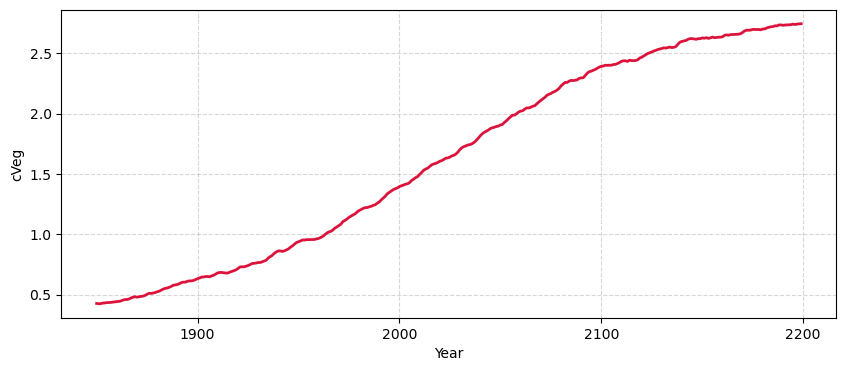

In [33]:
plt.figure(figsize=(10,4))
arctic_annual.plot(color='crimson',linewidth=2)
plt.ylabel("cVeg")
plt.xlabel("Year")
plt.grid(True, linestyle='--',alpha=0.5)
#plt.title("Arctic Vegetation cVeg Annual Trend (1850-2199)")
plt.show()

In [34]:
time_windows = {
    "Historical Baseline (1850-1879)": slice("1850-01-01", "1879-12-31"),
    "Peak Forcing Period (2070-2099)": slice("2070-01-01", "2099-12-31"),
    "Late Simulation Period (2170-2199)": slice("2170-01-01", "2199-12-31")
}

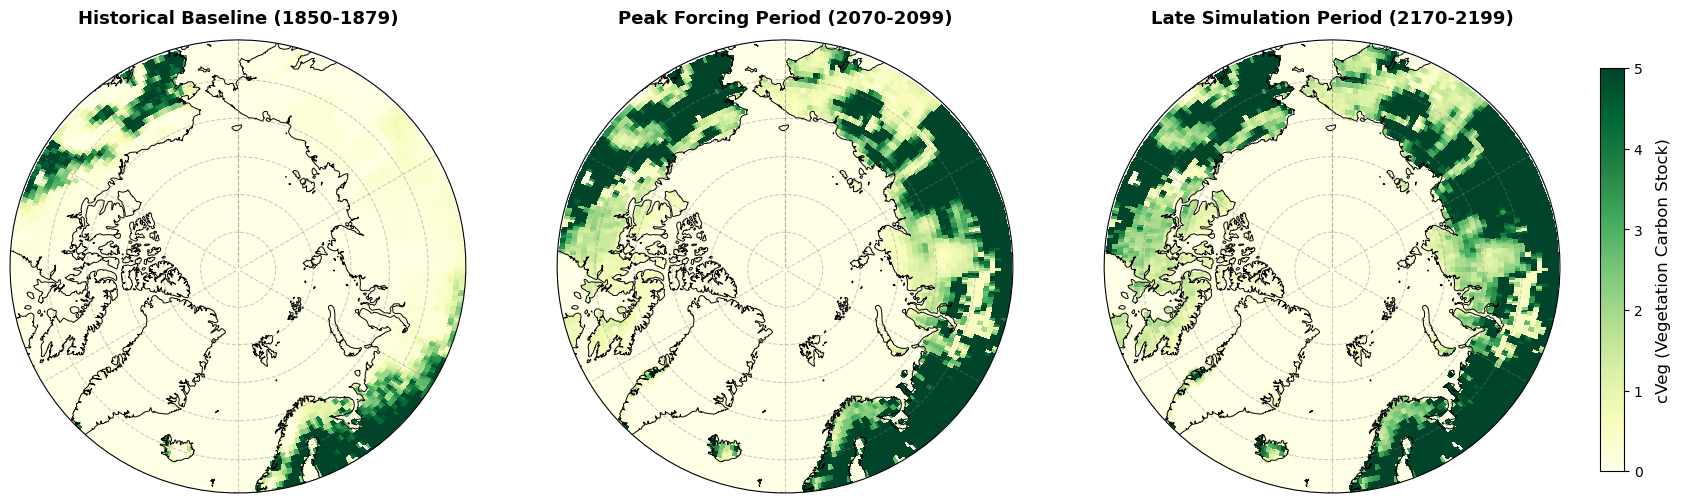

In [36]:
fig, axes = plt.subplots(
    1, 3, 
    figsize=(20, 6.5), 
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    gridspec_kw={'wspace': 0.2}
)

for ax, (title, time_slice) in zip(axes, time_windows.items()):
    data_mean = ds_arctic['cVeg'].sel(time=time_slice).mean(dim='time')
    
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    p = data_mean.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        x='lon', y='lat',
        cmap='YlGn',
        vmin=0, vmax=5,
        add_colorbar=False,
        robust=True
    )
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='black')
    ax.gridlines(draw_labels=False, crs=ccrs.PlateCarree(), linestyle='--', color='gray', alpha=0.4)
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

cbar_ax = fig.add_axes([0.92, 0.18, 0.012, 0.62]) 
cbar = fig.colorbar(p, cax=cbar_ax)
cbar.set_label('cVeg (Vegetation Carbon Stock)', fontsize=12, labelpad=10)

#plt.suptitle("Arctic Vegetation Carbon Spatial Dynamics Across Key Epochs", fontsize=16, fontweight='bold', y=1.02)
fig.savefig("Arctic_EC.png", dpi=300, bbox_inches='tight')
plt.show()